# iniz

In [4]:
import numpy as np
import pandas as pd
import pickle
import glob
import os
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyfit

In [5]:
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["axes.formatter.useoffset"]=False
title_fs = 16
label_fs = 15
tick_fs = 14
legend_fs = 14

In [6]:
def get_scaling_threshold(volumes: np.ndarray, driving_sds: np.ndarray, margin: float = 0.05):
    """Fits sigma = A * V^m and returns a predictor function."""
    log_V = np.log(volumes)
    log_sigma = np.log(driving_sds)
    
    # polyfit returns [intercept, slope]
    coefficients = polyfit(log_V, log_sigma, 1)
    log_A_fit = coefficients[0]
    m_fit = coefficients[1] 
    A_fit = np.exp(log_A_fit)
    
    print(f"Regression Results:")
    print(f" - Fitted Scaling Constant A: {A_fit:.3f}")
    print(f" - Fitted slope m: {m_fit:.3f} (Theoretical expected: -0.5)")
    
    def threshold_function(V_new: float) -> float:
        if V_new <= 0: raise ValueError("Volume must be positive.")
        predicted_sigma = A_fit * (V_new) ** m_fit
        return predicted_sigma * (1 + margin)

    return threshold_function, A_fit, m_fit

# fit with different k values

In [7]:
# --- 1. DATA LOADING AND AGGREGATION ---

# Find all results files generated by the HPC script
pkl_files = glob.glob("resultsv5_V_*.pkl")

data_list = []

for file in pkl_files:
    with open(file, "rb") as f:
        content = pickle.load(f)
        # content is {Volume: [rep1_stds, rep2_stds, ...]}
        for volume, reps_stds in content.items():
            if not reps_stds: continue
            
            # Convert to numpy for easier manipulation: shape (REPS, N_SPECIES)
            reps_stds = np.array(reps_stds)
            
            # Aggregate replicates: Calculate the mean SD for each species at this volume
            mean_stds = np.mean(reps_stds, axis=0)
            
            # Store with volume for sorting later
            data_list.append((volume, mean_stds))

# Sort by volume to ensure plots look correct
data_list.sort(key=lambda x: x[0])
volumes = np.array([x[0] for x in data_list])
all_mean_stds = np.array([x[1] for x in data_list]) # Shape: (Volumes, Species)

In [8]:
# --- 2. IDENTIFY DRIVING SPECIES ---
# Based on the sorting in fun_gilles.py: ['a', 'b', 'c', 'd', 'ab', 'cd', 'acd', 'cab']
# Indices 4, 5, 6, 7 correspond to the complexes/autocatalytic species
driving_species_indices = [4, 5, 6, 7] 
relevant_sds = all_mean_stds[:, driving_species_indices]

# The 'driving' SD is the maximum noise among the autocatalytic species
driving_SD = np.max(relevant_sds, axis=1)

In [9]:
# --- 3. FITTING THE SCALING LAW ---

# Generate predictors
threshold_predictor = get_scaling_threshold(volumes, driving_SD, margin=0.0)[0]
threshold_predictor_w_margin = get_scaling_threshold(volumes, driving_SD, margin=0.5)[0]

Regression Results:
 - Fitted Scaling Constant A: 1.779
 - Fitted slope m: -0.970 (Theoretical expected: -0.5)
Regression Results:
 - Fitted Scaling Constant A: 1.779
 - Fitted slope m: -0.970 (Theoretical expected: -0.5)


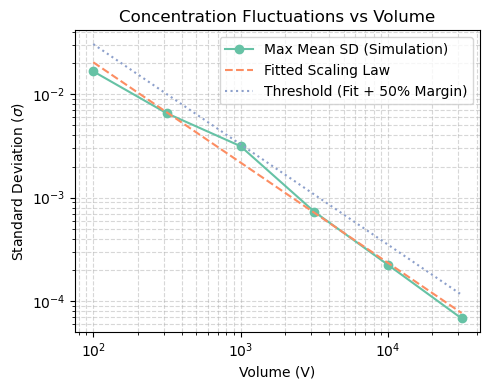

In [10]:
# --- 4. VISUALIZATION ---

plt.figure(figsize=(5,4))
colors = plt.get_cmap('Set2').colors

# Plot actual data
plt.loglog(volumes, driving_SD, 'o-', color=colors[0], label='Max Mean SD (Simulation)')

# Plot fits
v_range = np.logspace(np.log10(volumes.min()), np.log10(volumes.max()), 100)
plt.loglog(v_range, [threshold_predictor(v) for v in v_range], 
           '--', color=colors[1], label='Fitted Scaling Law')
plt.loglog(v_range, [threshold_predictor_w_margin(v) for v in v_range], 
           ':', color=colors[2], label='Threshold (Fit + 50% Margin)')

plt.xlabel('Volume (V)')
plt.ylabel(r'Standard Deviation ($\sigma$)')
plt.title('Concentration Fluctuations vs Volume')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("sd_vs_vol_fit.png")
plt.show()

In [11]:
# --- 5. R-SQUARED CALCULATION ---
y_obs = np.log(driving_SD)
y_pred = np.log([threshold_predictor(v) for v in volumes])
ss_res = np.sum((y_obs - y_pred)**2)
ss_tot = np.sum((y_obs - np.mean(y_obs))**2)
r2_log = 1 - (ss_res / ss_tot)

print(f"Log-Log R-squared: {r2_log:.4f}")

Log-Log R-squared: 0.9913


Now, I want to see if this fit is valid for different k values, so I will loop over the different simulation results.

Results for file :
Regression Results:
 - Fitted Scaling Constant A: 2.719
 - Fitted slope m: -0.884 (Theoretical expected: -0.5)


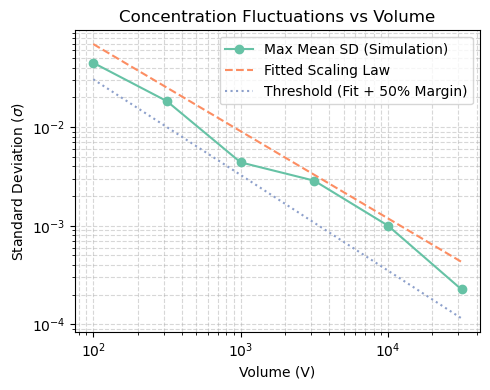

Results for file v2:
Regression Results:
 - Fitted Scaling Constant A: 0.742
 - Fitted slope m: -0.984 (Theoretical expected: -0.5)


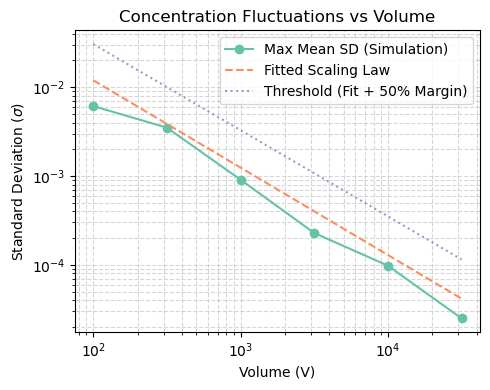

Results for file v3:
Regression Results:
 - Fitted Scaling Constant A: 0.121
 - Fitted slope m: -0.722 (Theoretical expected: -0.5)


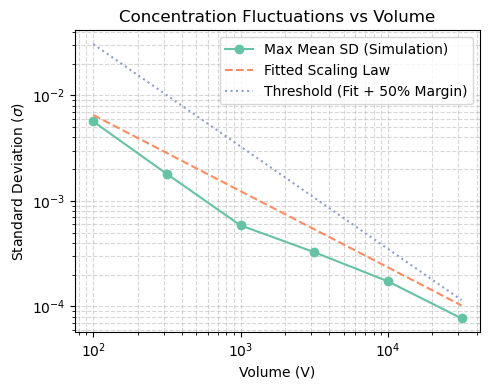

Results for file v4:
Regression Results:
 - Fitted Scaling Constant A: 0.888
 - Fitted slope m: -0.954 (Theoretical expected: -0.5)


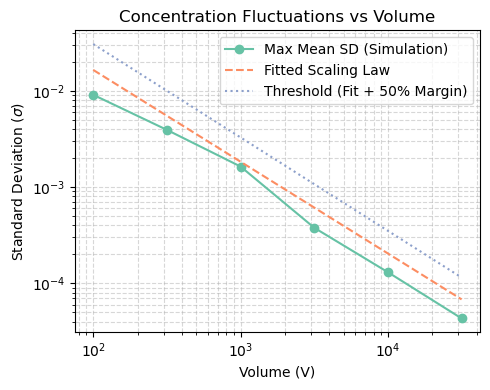

Results for file v5:
Regression Results:
 - Fitted Scaling Constant A: 1.779
 - Fitted slope m: -0.970 (Theoretical expected: -0.5)


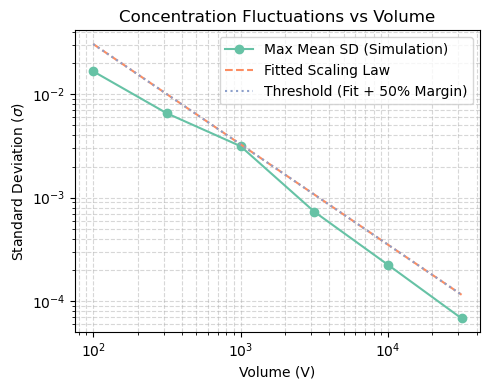

In [12]:
for i in ["", "v2", "v3","v4","v5"]:
    pkl_files = glob.glob(f"results{i}_V_*.pkl")

    data_list = []

    for file in pkl_files:
        with open(file, "rb") as f:
            content = pickle.load(f)
            # content is {Volume: [rep1_stds, rep2_stds, ...]}
            for volume, reps_stds in content.items():
                if not reps_stds: continue
                
                # Convert to numpy for easier manipulation: shape (REPS, N_SPECIES)
                reps_stds = np.array(reps_stds)
                
                # Aggregate replicates: Calculate the mean SD for each species at this volume
                mean_stds = np.mean(reps_stds, axis=0)
                
                # Store with volume for sorting later
                data_list.append((volume, mean_stds))

    # Sort by volume to ensure plots look correct
    data_list.sort(key=lambda x: x[0])
    volumes = np.array([x[0] for x in data_list])
    all_mean_stds = np.array([x[1] for x in data_list]) # Shape: (Volumes, Species)

    driving_species_indices = [4, 5, 6, 7] 
    relevant_sds = all_mean_stds[:, driving_species_indices]

    # The 'driving' SD is the maximum noise among the autocatalytic species
    driving_SD = np.max(relevant_sds, axis=1)
    print(f"Results for file {i}:")
    threshold_predictor = get_scaling_threshold(volumes, driving_SD, margin=0.5)[0]
    # --- 4. VISUALIZATION ---

    plt.figure(figsize=(5,4))
    colors = plt.get_cmap('Set2').colors

    # Plot actual data
    plt.loglog(volumes, driving_SD, 'o-', color=colors[0], label='Max Mean SD (Simulation)')

    # Plot fits
    v_range = np.logspace(np.log10(volumes.min()), np.log10(volumes.max()), 100)
    plt.loglog(v_range, [threshold_predictor(v) for v in v_range], 
            '--', color=colors[1], label='Fitted Scaling Law')
    plt.loglog(v_range, [threshold_predictor_w_margin(v) for v in v_range], 
            ':', color=colors[2], label='Threshold (Fit + 50% Margin)')

    plt.xlabel('Volume (V)')
    plt.ylabel(r'Standard Deviation ($\sigma$)')
    plt.title('Concentration Fluctuations vs Volume')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig("sd_vs_vol_fit.png")
    plt.show()


# fit with random k values

In [13]:
pkl_files = glob.glob("results_random_k/results_random_V*_K*.pkl")
all_results = []

for file in pkl_files:
    with open(file, "rb") as f:
        all_results.append(pickle.load(f))

# all_results = [{'volume': 100, 'k_idx': 0, 'stds': [[...], [...]]}, ...]

data = []
for entry in all_results:
    v = entry['volume']
    k_id = entry['k_idx']
    # Mean across 5 reps for this specific (V, K)
    mean_std_per_species = np.mean(entry['stds'], axis=0) 
    # Use max SD of the driving species (indices 4:8)
    driving_sd = np.max(mean_std_per_species[4:])
    data.append([v, k_id, driving_sd])

In [14]:
# 1. Extract the Max SD for every (Volume, K_set)
processed_data = []
for entry in all_results:
    # Average across replicates first
    mean_reps = np.mean(entry['stds'], axis=0)
    
    # Identify the max noise among driving species
    driving_sd = np.max(mean_reps[4:8]) 
    
    processed_data.append({
        'Volume': entry['volume'],
        'K_Set': entry['k_idx'],
        'Max_SD': driving_sd
    })

df = pd.DataFrame(processed_data)

# 2. Group by Volume and calculate Mean and SEM
# We use a lambda to calculate SEM directly from the group of K-sets
stats = df.groupby('Volume')['Max_SD'].agg([
    'mean', 
    'std', 
    ('sem', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
]).reset_index()

# 3. Extract for plotting
v_fit = stats['Volume'].values
sd_means = stats['mean'].values
sd_errors = stats['std'].values # Use 'sem' here instead of 'std' for cleaner bars

Regression Results:
 - Fitted Scaling Constant A: 0.374
 - Fitted slope m: -0.930 (Theoretical expected: -0.5)


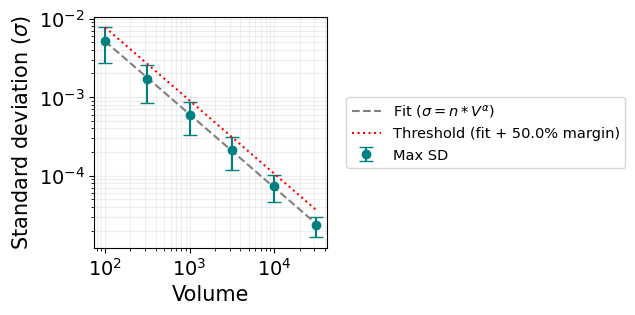

In [28]:

# --- FITTING ---
# Fit the threshold function to the MEANS
threshold_predictor_no_margin = get_scaling_threshold(v_fit, sd_means, margin=0.0)[0]

# --- PLOTTING ---
plt.figure(figsize=(3,3))

# Plot the Mean SD with error bars representing the variation across K-sets
plt.errorbar(v_fit, sd_means, yerr=sd_errors, fmt='o', capsize=5, 
             label='Max SD', color='teal')

# Plot the Fitted Function
v_range = np.logspace(np.log10(v_fit.min()), np.log10(v_fit.max()), 100)
plt.loglog(v_range, [threshold_predictor_no_margin(v) for v in v_range], 
           '--', color='gray', label=r'Fit ($\sigma = n * V^\alpha$)')

# Manually set a margin to "envelop" the data
manual_margin = 0.5 
plt.loglog(v_range, [threshold_predictor_no_margin(v) * (1 + manual_margin) for v in v_range], 
           ':', color='red', label=f'Threshold (fit + {manual_margin*100}% margin)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Volume', fontsize=label_fs)
plt.ylabel(r'Standard deviation ($\sigma$)', fontsize=label_fs)
plt.legend(fontsize=legend_fs-3.5, loc='center left', bbox_to_anchor=(1.05, 0.5),)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tick_params(axis='both', labelsize=tick_fs)
plt.savefig("../figures_TFM/sd_vs_vol_random_k.png", bbox_inches='tight')
# plt.title('Mean noise with random k-sets for different volumes', fontsize=title_fs)
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\cvzad\AppData\Local\Temp\ipykernel_26724\1841329444.py:22: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Max Standard Deviation ($\sigma_{max}$)', fontsize=12)


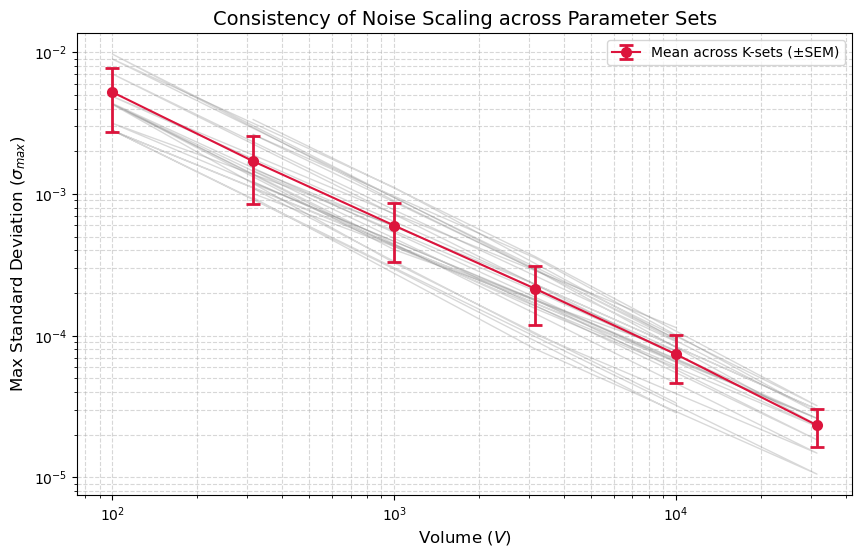

In [16]:
import matplotlib.pyplot as plt

# Assuming 'df' is your long-form dataframe (50 rows: Volume, K_Set, Max_SD)
# And 'stats' is your aggregated dataframe (5 rows: Volume, mean, sem)

plt.figure(figsize=(10, 6))

# 1. Plot individual K-sets (The "Spaghetti")
for k_idx in df['K_Set'].unique():
    subset = df[df['K_Set'] == k_idx]
    plt.plot(subset['Volume'], subset['Max_SD'], color='gray', alpha=0.3, lw=1, label='_nolegend_')

# 2. Plot the Mean with SEM Error Bars
plt.errorbar(stats['Volume'], stats['mean'], yerr=stats['std'], 
             fmt='-o', color='crimson', capsize=5, elinewidth=2, markeredgewidth=2,
             label='Mean across K-sets (±SEM)')

# 3. Formatting for Log-Log or Semi-Log
plt.xscale('log')
plt.yscale('log') # Noise scaling usually looks linear on log-log plots
plt.xlabel('Volume ($V$)', fontsize=12)
plt.ylabel('Max Standard Deviation ($\sigma_{max}$)', fontsize=12)
plt.title('Consistency of Noise Scaling across Parameter Sets', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.show()

In [17]:
all_results

[{'volume': 10000,
  'k_idx': 0,
  'k_values': array([6.94535626e+03, 9.23811992e-05, 1.01467174e+05, 3.32092289e-03,
         1.65708060e+04, 1.15640638e-04, 6.51901951e+03, 1.74747514e-01]),
  'stds': [[7.182351486744724e-08,
    7.182351486744724e-08,
    7.182351486744724e-08,
    7.182351486744724e-08,
    0.00018468085889774224,
    8.834804612900147e-05,
    0.00013105802395832358,
    0.0001448201561141539],
   [6.441853770988453e-08,
    6.441853770988453e-08,
    6.441853770988453e-08,
    6.441853770988453e-08,
    9.010117016012859e-05,
    2.6352337909624802e-05,
    3.568488542271022e-05,
    9.965739163656596e-05],
   [4.658363498008877e-06,
    4.658363498008877e-06,
    4.658363498008877e-06,
    4.658363498008877e-06,
    0.0001214649907360315,
    6.912471444548015e-05,
    8.179924977765e-05,
    0.00013531157135221803],
   [5.802006981853956e-08,
    5.802006981853956e-08,
    5.802006981853956e-08,
    5.802006981853956e-08,
    6.696008348503927e-05,
    4.015806

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

processed_data = []

for entry in stats:
    # 1. Stability Check: Filter out runs that failed or didn't reach steady state
    # We check if the mean concentration is above a tiny threshold
    if np.any(np.isnan(entry['stds'])) or np.mean(entry['mean']) < 1e-6:
        continue # Skip this entry

    # 2. Average across your REPS
    # entry['stds'] shape: (REPS, N_SPECIES)
    mean_reps_sd = np.mean(entry['stds'], axis=0)
    
    # 3. Identify the driving species (indices 4, 5, 6, 7)
    driving_sd = np.max(mean_reps_sd[4:8]) 
    
    # 4. Check if the K_set index is Even or Odd for your records
    # (Though your simulation code is what actually fixes the values, 
    # we tag it here for the plot labels)
    k_type = 'Variable (Odd)' if entry['k_idx'] % 2 != 0 else 'Fixed (Even)'

    processed_data.append({
        'Volume': entry['volume'],
        'K_Set': entry['k_idx'],
        'K_Type': k_type,
        'Max_SD': driving_sd
    })

df = pd.DataFrame(processed_data)

# Calculate stats for the bold line
stats = df.groupby('Volume')['Max_SD'].agg([
    'mean', 
    ('sem', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
]).reset_index()

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# Plot the individual paths
for k_idx in df['K_Set'].unique():
    subset = df[df['K_Set'] == k_idx]
    # We can color them differently if you like, but gray keeps it clean
    plt.plot(subset['Volume'], subset['Max_SD'], color='gray', alpha=0.3, lw=1)

# Plot the aggregate mean
plt.errorbar(stats['Volume'], stats['mean'], yerr=stats['sem'], 
             fmt='-o', color='blue', capsize=5, label='Mean of Mixed K-sets')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Volume')
plt.ylabel('Max SD (Driving Species)')
plt.title('Noise Scaling: Fixed Even K vs. Variable Odd K')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

TypeError: string indices must be integers, not 'str'

## outlier

In [ ]:
pkl_files = glob.glob("results_random_k/results_random_V*_K*.pkl")
all_rows = []

# This list matches your SPECIES ordering: ['a', 'b', 'c', 'd', 'ab', 'cd', 'acd', 'cab']
species_names = ['a', 'b', 'c', 'd', 'ab', 'cd', 'acd', 'cab']

for file in pkl_files:
    with open(file, "rb") as f:
        data = pickle.load(f)
        
        # Calculate the mean SD across the 5 replicates for this run
        # data['stds'] has shape (5, 8)
        mean_stds = np.mean(data['stds'], axis=0)
        
        # Create a dictionary for this specific run
        row = {
            'V': data['volume'],
            'K_idx': data['k_idx']
        }
        
        # Add each species SD as a separate column
        for i, name in enumerate(species_names):
            row[name] = mean_stds[i]
            
        all_rows.append(row)

df = pd.DataFrame(all_rows)

# Sort by Volume and then K_idx for easy reading
df = df.sort_values(['V', 'K_idx']).reset_index(drop=True)

# Display the dataframe
print("Full Simulation Results:")
df

Full Simulation Results:


,V,K_idx,a,b,c,d,ab,cd,acd,cab
0,100,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.011903,0.000600,0.000000e+00,0.011908
1,100,1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.008376,0.008713,6.948254e-03,0.011986
2,100,2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.028810,0.002099,3.158241e-04,0.028892
3,100,3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.034990,0.002889,2.736776e-03,0.034974
4,100,4,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.004842,0.004956,5.142547e-03,0.000435
5,100,5,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.007246,7.246377e-03,0.000000
6,100,6,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.005434,0.002483,4.046581e-03,0.001484
7,100,7,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.001551,0.009402,4.018249e-05,0.009446
8,100,8,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.013758,0.015297,1.230608e-02,0.003789
9,100,9,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.012980,0.012819,8.430160e-04,0.004292


In [ ]:
# Filter only for Volume 1000
outlier_check = df[df['V'] == 1000]

print("\n--- Detailed view of Volume 1000 ---")
print(outlier_check)

# To find which K_idx had the absolute maximum noise at this volume:
idxmax = outlier_check[['ab', 'cd', 'acd', 'cab']].max(axis=1).idxmax()
print(f"\nThe row with the highest noise at V=1000 is index: {idxmax}")
print(df.loc[idxmax])

idxmin = outlier_check[['ab', 'cd', 'acd', 'cab']].min(axis=1).idxmin()
print(f"\nThe row with the lowest noise at V=1000 is index: {idxmin}")
print(df.loc[idxmin])


--- Detailed view of Volume 1000 ---
       V  K_idx             a             b             c             d  \
20  1000      0  1.066891e-07  1.066891e-07  1.066891e-07  1.066891e-07   
21  1000      1  1.533321e-06  1.533321e-06  1.533321e-06  1.533321e-06   
22  1000      2  1.191263e-06  1.191263e-06  1.191263e-06  1.191263e-06   
23  1000      3  2.331468e-16  2.331468e-16  2.331468e-16  2.331468e-16   
24  1000      4  6.697489e-06  6.697489e-06  6.697489e-06  6.697489e-06   
25  1000      5  5.639933e-15  5.639933e-15  5.639933e-15  5.639933e-15   
26  1000      6  6.894547e-06  6.894547e-06  6.894547e-06  6.894547e-06   
27  1000      7  4.647444e-05  4.647444e-05  4.647444e-05  4.647444e-05   
28  1000      8  3.074251e-06  3.074251e-06  3.074251e-06  3.074251e-06   
29  1000      9  2.553816e-06  2.553816e-06  2.553816e-06  2.553816e-06   

          ab        cd       acd       cab  
20  0.002246  0.000054  0.000000  0.002245  
21  0.001067  0.000969  0.000767  0.001508  
2